
# Fase 2 — Análisis inferencial
## Acceso a Internet en los hogares paraguayos — EPHC 2025

**Objetivo:** contrastar las cinco hipótesis derivadas de la Fase 1.

**Decisiones fijadas antes del análisis**
- Nivel de significancia: α = 0,05.
- Corrección por comparaciones múltiples: **Bonferroni**.
- Semilla bootstrap: 42.
- Unidad de análisis: hogar.
- Variable objetivo del proyecto: `TIENE_INTERNET`.

> **Limitación:** la EPHC utiliza un diseño muestral complejo y cada hogar posee `FACTOR`. Las pruebas estándar de `scipy.stats` usadas en esta fase no modelan explícitamente el diseño complejo ni sus varianzas. `FACTOR` se conserva para trazabilidad, pero no se usa como peso en estos contrastes.



## 1. Carga y revisión de datos


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, shapiro, levene

df = pd.read_csv("dataset_limpio_internet_hogares.csv")

print("Dimensiones:", df.shape)
display(df.head())

variables = [
    "AREA_DESC", "TIENE_INTERNET", "NIVEL_EDUC_JEFE",
    "IPCM", "ANIOS_ESTUDIO_JEFE", "TOTAL"
]
display(df[variables].isna().sum().to_frame("faltantes"))


Dimensiones: (17092, 21)


,UPM,NVIVI,NHOGA,DPTO,DPTO_NOMBRE,AREA,AREA_DESC,TOTAL,V23A1,TIENE_INTERNET,V23C1,V23C2,EDAD_JEFE,SEXO_JEFE_DESC,ANIOS_ESTUDIO_JEFE,NIVEL_EDUC_JEFE,CAT_OCUP_JEFE_DESC,IPCM,QUINTIL_ING,DECIL_ING,FACTOR
0,14,13,1,0,Asunción,1,Urbana,2,1,1,1.0,6.0,65,Hombre,15.0,4. Superior (13+ años),Inactivo/No aplica,9.470323e+06,5,10,100
1,14,15,1,0,Asunción,1,Urbana,2,6,0,NaN,NaN,78,Hombre,6.0,2. Básica completa (6-9 años),Inactivo/No aplica,2.080500e+06,4,7,124
2,14,16,1,0,Asunción,1,Urbana,3,1,1,1.0,6.0,40,Hombre,17.0,4. Superior (13+ años),Empleado/a privado/a,3.535490e+06,5,9,138
3,14,26,1,0,Asunción,1,Urbana,2,6,1,1.0,6.0,32,Hombre,12.0,3. Media/Bachillerato (10-12 años),Empleado/a privado/a,3.671471e+06,5,9,183
4,14,35,1,0,Asunción,1,Urbana,2,6,1,1.0,6.0,24,Hombre,12.0,3. Media/Bachillerato (10-12 años),Empleado/a privado/a,3.457301e+06,5,9,120


,faltantes
AREA_DESC,0
TIENE_INTERNET,0
NIVEL_EDUC_JEFE,2
IPCM,0
ANIOS_ESTUDIO_JEFE,2
TOTAL,0



## 2. Hipótesis estadísticas

### H1 — Área e Internet
- H₀: p_urbana = p_rural.
- H₁: p_urbana ≠ p_rural.
- Natural: la proporción de hogares con Internet es igual en ambas áreas frente a la alternativa de que sea distinta.

### H2 — Educación e Internet
- H₀: acceso a Internet y nivel educativo son independientes.
- H₁: al menos una proporción educativa difiere.
- Natural: el nivel educativo del jefe/a no guarda relación con Internet frente a la alternativa de que sí guarda relación.

### H3 — Ingreso e Internet
- H₀: la distribución de `IPCM` es igual en hogares con y sin Internet.
- H₁: las distribuciones difieren.
- Natural: conectados y no conectados tienen la misma distribución de ingresos frente a la alternativa de que difieren.

### H4 — Años de estudio e ingreso
- H₀: ρ = 0.
- H₁: ρ ≠ 0.
- Natural: años de estudio e ingreso no tienen relación monotónica frente a la alternativa de que sí la tienen.

### H5 — Tamaño del hogar e Internet
- H₀: la distribución de `TOTAL` es igual en hogares con y sin Internet.
- H₁: las distribuciones difieren.
- Natural: el tamaño del hogar no se relaciona con Internet frente a la alternativa de que sí se relaciona.



## 3. Verificación de supuestos

**Independencia:** depende principalmente del diseño de observación. La unidad es el hogar, pero el diseño complejo de la EPHC no se modela explícitamente en estas pruebas; por eso se documenta como limitación.

**Normalidad:** se verifica con Shapiro-Wilk y Q-Q. Para evitar una sensibilidad excesiva por el tamaño muestral, Shapiro se calcula sobre una submuestra de hasta 5.000 casos.

**Homogeneidad de varianzas:** se verifica con Levene como diagnóstico complementario.

Para H3 y H5, si la normalidad no resulta razonable, se utiliza Mann-Whitney en vez de una comparación paramétrica simple de medias. H1 y H2 son categóricas, por lo que Shapiro y Levene no aplican. H4 usa Spearman, que no requiere normalidad bivariada.


IPCM | Shapiro-Wilk W=0.553952, p=1.063e-77


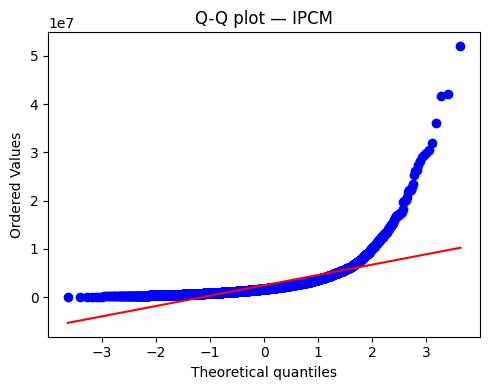

IPCM | Levene=167.175542, p=4.620e-38

TOTAL | Shapiro-Wilk W=0.897993, p=1.518e-49


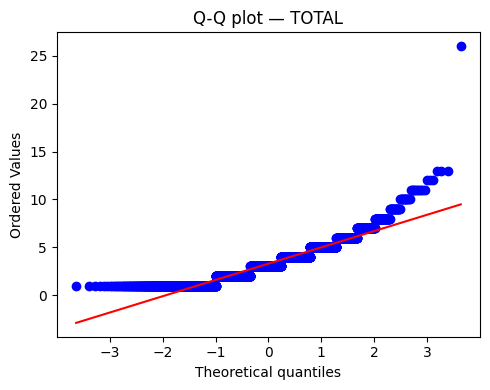

TOTAL | Levene=29.293468, p=6.304e-08



In [2]:

for variable in ["IPCM", "TOTAL"]:
    serie = df[variable].dropna()
    muestra = serie.sample(
        n=min(5000, len(serie)),
        random_state=42
    )

    W, p_shapiro = shapiro(muestra)
    print(f"{variable} | Shapiro-Wilk W={W:.6f}, p={p_shapiro:.3e}")

    plt.figure(figsize=(5,4))
    stats.probplot(muestra, dist="norm", plot=plt)
    plt.title(f"Q-Q plot — {variable}")
    plt.tight_layout()
    plt.show()

    grupo_con = df.loc[df.TIENE_INTERNET == 1, variable].dropna()
    grupo_sin = df.loc[df.TIENE_INTERNET == 0, variable].dropna()
    stat_lev, p_lev = levene(grupo_con, grupo_sin, center="median")
    print(f"{variable} | Levene={stat_lev:.6f}, p={p_lev:.3e}\n")



### Decisión sobre los supuestos

Los diagnósticos muestran fuerte desviación de normalidad en `IPCM` y `TOTAL` y diferencias de varianzas entre los grupos. Esto respalda mantener **Mann-Whitney** para H3 y H5.

La independencia no se prueba con un test estadístico simple y debe interpretarse según el diseño de la encuesta.
